# ALS matrix factorization for rating prediction

Explicit-feedback matrix factorization of the **user × recipe** rating matrix, fitted by **alternating least squares** (ALS).

**Data** (`input_stage2/recipe_user_ratings.csv`)

- The target is `rating`. Only ratings of 1 or more count; rating 0 is a review without stars.
- If a user rated the same recipe more than once, only the latest rating is kept.
- Only users with at least 6 ratings are kept. Every row of the other users is discarded.
- **Split**, per user by date: the latest rating is **test**, the one before it is **valid**, and the rest (at least 4) are **train**.
  Valid picks the regularization strengths and the iteration to keep. Test is used only for the final report.

**Model and loss**

$$\hat r_{ui} = \mu + b_u + c_i + p_u^\top q_i$$

$\mu$ is the train mean, $b_u$ and $c_i$ are the user and recipe biases, and $p_u, q_i \in \mathbb{R}^k$ are the latent factors.
Training minimizes the squared error plus an **L2 penalty**:

$$L = \sum_{(u,i) \in \text{train}} \big(r_{ui} - \hat r_{ui}\big)^2 + \lambda \Big(\sum_u \lVert p_u \rVert^2 + \sum_i \lVert q_i \rVert^2\Big) + \lambda_b \Big(\sum_u b_u^2 + \sum_i c_i^2\Big)$$

**ALS.** With every recipe's $(q_i, c_i)$ fixed, $L$ splits into one ridge regression per user, which has a closed-form solution:

$$\begin{bmatrix} p_u \\ b_u \end{bmatrix} = \big(Z_u^\top Z_u + \Lambda\big)^{-1} Z_u^\top \big(r_u - \mu - c_{I_u}\big), \qquad Z_u = \begin{bmatrix} q_i^\top & 1 \end{bmatrix}_{i \in I_u}, \qquad \Lambda = \operatorname{diag}(\lambda, \dots, \lambda, \lambda_b)$$

$I_u$ is the set of recipes user $u$ rated in train, and $r_u$ holds those ratings. The recipe step is the same with users and recipes swapped.
Each step minimizes $L$ exactly over the parameters it updates, so $L$ never increases.

**Why the penalty matters.** Without it, a recipe with a single train rating could fit that rating exactly.
With it, parameters backed by few ratings stay close to 0: in the biases-only model, a recipe bias learned from $n$ ratings is their mean residual times $n / (n + \lambda_b)$.
A small $\lambda$ gives a low train RMSE but a high valid RMSE (overfitting). A very large $\lambda$ shrinks every factor to 0, which leaves the biases-only model.

**Tuning.** $\lambda_b$ is picked first on a **biases-only** model ($k = 0$), which is also the bias baseline.
Then $\lambda$ is picked for the $k$-factor model with that $\lambda_b$. Both choices use valid RMSE, and every run stops early on valid RMSE.
A recipe with no train rating gets $q_i = 0$ and $c_i = 0$, so its prediction falls back to $\mu + b_u$.

In [1]:
# Run once if these packages are missing, then restart the notebook kernel.
# %pip install numpy pandas scipy matplotlib
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from IPython.display import display

In [2]:
RANDOM_STATE = 42
NOTEBOOK_DIR = next((p for p in (Path.cwd(), Path.cwd() / "DataMappingRecommendation")
                     if (p / "input_stage2/recipe_user_ratings.csv").is_file()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Run from DataMappingRecommendation or its project root.")
DATA_PATH = NOTEBOOK_DIR / "input_stage2/recipe_user_ratings.csv"
ALS_DIR = NOTEBOOK_DIR / "model_artifacts/mf_als"

RATING_MIN, RATING_MAX = 1, 5  # Rows rated below RATING_MIN (0 = a review without stars) are dropped; predictions are clipped to this range.
MIN_USER_RATINGS = 6  # Users with fewer ratings are discarded, with all their rows.

FACTORS = 32  # k: the size of p_u and q_i.
L2_BIAS_GRID = [1.0, 3.0, 10.0, 30.0]  # lambda_b candidates, tried on the biases-only model.
L2_GRID = [1.0, 3.0, 10.0, 30.0, 100.0, 300.0]  # lambda candidates for the factors.
INIT_STD = 0.1  # q_i starts as N(0, INIT_STD^2); the first user step solves the user side from it.
MAX_ITERATIONS = 25  # One iteration is a user step followed by a recipe step.
EARLY_STOPPING_PATIENCE = 3  # Stop after this many iterations without a better valid RMSE,
MIN_IMPROVEMENT = 1e-4  # where better means lower by more than this.
CHUNK_ELEMENTS = 2**22  # At most this many float64 values (32 MB) per batch of normal equations.
print(f"Ratings: {DATA_PATH}\nArtifacts: {ALS_DIR}")

Ratings: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/input_stage2/recipe_user_ratings.csv
Artifacts: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/mf_als


## Data: ratings of 1–5, users with at least 6 ratings, split per user by date

In [3]:
source = pd.read_csv(DATA_PATH, usecols=["user_id", "recipe_id", "rating", "date"])
rated = source[source["rating"] >= RATING_MIN].assign(date=lambda frame: pd.to_datetime(frame["date"], format="mixed"))
# One rating per (user, recipe): the latest.
ratings = rated.sort_values("date", kind="stable").drop_duplicates(["user_id", "recipe_id"], keep="last")
kept = ratings[ratings["user_id"].map(ratings["user_id"].value_counts()) >= MIN_USER_RATINGS]
print(f"{len(source):,} rows: {len(source) - len(rated):,} rated below {RATING_MIN} dropped, "
      f"{len(rated) - len(ratings):,} repeated (user, recipe) pairs merged -> {len(ratings):,} ratings "
      f"from {ratings['user_id'].nunique():,} users")
print(f"Users with >= {MIN_USER_RATINGS} ratings: {kept['user_id'].nunique():,} kept, with {len(kept):,} ratings on "
      f"{kept['recipe_id'].nunique():,} recipes; {ratings['user_id'].nunique() - kept['user_id'].nunique():,} users "
      f"and their {len(ratings) - len(kept):,} ratings discarded")

# Per user, by date: the latest rating is test, the one before it valid, the rest train. Same-day ties keep file order.
kept = kept.sort_values(["user_id", "date"], kind="stable").reset_index(drop=True)
from_end = kept.groupby("user_id").cumcount(ascending=False).to_numpy()  # 0 = the user's latest rating
split = np.select([from_end == 0, from_end == 1], ["test", "valid"], "train")
splits = {name: kept[split == name].reset_index(drop=True) for name in ("train", "valid", "test")}

train_recipe_ids = set(splits["train"]["recipe_id"])
split_summary = pd.DataFrame({
    name: {"ratings": len(frame), "users": frame["user_id"].nunique(), "recipes": frame["recipe_id"].nunique(),
           "recipe not in train": (~frame["recipe_id"].isin(train_recipe_ids)).mean(),
           "mean rating": frame["rating"].mean(),
           **{f"share {r}★": frame["rating"].eq(r).mean() for r in range(RATING_MIN, RATING_MAX + 1)}}
    for name, frame in splits.items()}).T
display(split_summary.round(3))

1,132,367 rows: 60,847 rated below 1 dropped, 0 repeated (user, recipe) pairs merged -> 1,071,520 ratings from 196,098 users
Users with >= 6 ratings: 18,831 kept, with 829,411 ratings on 206,212 recipes; 177,267 users and their 242,109 ratings discarded


,ratings,users,recipes,recipe not in train,mean rating,share 1★,share 2★,share 3★,share 4★,share 5★
train,791749.0,18831.0,202600.0,0.000,4.688,0.005,0.010,0.038,0.186,0.761
valid,18831.0,18831.0,13196.0,0.094,4.689,0.013,0.016,0.036,0.140,0.796
test,18831.0,18831.0,13083.0,0.103,4.705,0.013,0.017,0.032,0.129,0.809


## Rating matrix

Users and recipes are indexed from **train** only. `R` is the train rating matrix (users × recipes, CSR), and its
transpose (recipes × users) drives the recipe step. A valid or test recipe that has no train rating gets index −1.

In [4]:
user_ids = np.sort(splits["train"]["user_id"].unique())
recipe_ids = np.sort(splits["train"]["recipe_id"].unique())
user_index, recipe_index = pd.Index(user_ids), pd.Index(recipe_ids)


def encode(frame):
    # (user index, recipe index, rating) arrays; a user or recipe that is not in train gets index -1.
    return (user_index.get_indexer(frame["user_id"]), recipe_index.get_indexer(frame["recipe_id"]),
            frame["rating"].to_numpy(np.float64))


encoded = {name: encode(frame) for name, frame in splits.items()}
train_users, train_recipes, train_values = encoded["train"]
R = sp.csr_matrix((train_values, (train_users, train_recipes)), shape=(len(user_ids), len(recipe_ids)))
per_user, per_recipe = np.diff(R.indptr), np.diff(R.tocsc().indptr)
print(f"R: {R.shape[0]:,} users x {R.shape[1]:,} recipes, {R.nnz:,} ratings (density {R.nnz / np.prod(R.shape):.3%})")
print(f"Train ratings per user: min {per_user.min()}, median {np.median(per_user):.0f}, max {per_user.max():,}; "
      f"per recipe: median {np.median(per_recipe):.0f}, max {per_recipe.max():,}, "
      f"{np.mean(per_recipe == 1):.0%} of recipes have one")

R: 18,831 users x 202,600 recipes, 791,749 ratings (density 0.021%)
Train ratings per user: min 4, median 11, max 7,663; per recipe: median 2, max 915, 44% of recipes have one


## ALS with L2 regularization

- `ridge_rows` is one half-step: a ridge regression for every row of a sparse target matrix, meaning every user or every recipe.
  Rows with the same number of ratings $c$ are stacked into a `[rows, c, k + 1]` array, so one batched matmul builds their
  $Z^\top Z$ and one `np.linalg.solve` call solves them.
- `fit_als` alternates the user and recipe steps. After each iteration it records the loss $L$ (and warns if it rises),
  the train RMSE, and the valid RMSE. It returns the iteration with the best valid RMSE, and it stops after
  `EARLY_STOPPING_PATIENCE` iterations without an improvement.
- Every RMSE uses predictions clipped to [1, 5]; $L$ uses the unclipped model.

In [5]:
def ridge_rows(targets, design, reg):
    """One ALS half-step: a ridge regression for every row of the CSR matrix `targets`.

    With t_r the row's stored values and Z_r = design[the row's columns], row r gets
        x_r = argmin_x ||t_r - Z_r x||^2 + sum_d reg_d * x_d^2 = (Z_r^T Z_r + diag(reg))^-1 Z_r^T t_r.
    """
    d = design.shape[1]
    solution = np.zeros((targets.shape[0], d))  # A row without ratings keeps x = 0.
    counts = np.diff(targets.indptr)
    for c in np.unique(counts[counts > 0]):
        same = np.flatnonzero(counts == c)
        step = max(1, CHUNK_ELEMENTS // ((c + d) * d))  # Rows per batch, to bound memory.
        for start in range(0, len(same), step):
            rows = same[start:start + step]
            at = targets.indptr[rows][:, None] + np.arange(c)  # [rows, c]: where each row's ratings are stored
            Z, t = design[targets.indices[at]], targets.data[at]  # [rows, c, d], [rows, c]
            gram = np.swapaxes(Z, 1, 2) @ Z + np.diag(reg)  # Z^T Z + diag(reg)
            rhs = np.einsum("rcd,rc->rd", Z, t)  # Z^T t
            solution[rows] = np.linalg.solve(gram, rhs[..., None])[..., 0]
    return solution


def predict(model, users, recipes, clip=True):
    # mu + b_u + c_i + p_u . q_i. A user or recipe outside train (index -1) adds nothing.
    pred = np.full(len(users), model["mu"])
    known_user, known_recipe = users >= 0, recipes >= 0
    pred[known_user] += model["user_bias"][users[known_user]]
    pred[known_recipe] += model["item_bias"][recipes[known_recipe]]
    both = known_user & known_recipe
    pred[both] += np.einsum("nk,nk->n", model["user_factors"][users[both]], model["item_factors"][recipes[both]])
    return pred.clip(RATING_MIN, RATING_MAX) if clip else pred


def regression_metrics(y, pred):
    error = pred - y
    return {"mse": float(np.mean(error ** 2)), "rmse": float(np.sqrt(np.mean(error ** 2))),
            "mae": float(np.mean(np.abs(error)))}


def als_loss(model, R, users, l2, l2_bias):
    # L: squared error on train plus the L2 penalties.
    error = R.data - predict(model, users, R.indices, clip=False)
    factors = (model["user_factors"] ** 2).sum() + (model["item_factors"] ** 2).sum()
    biases = (model["user_bias"] ** 2).sum() + (model["item_bias"] ** 2).sum()
    return float(error @ error + l2 * factors + l2_bias * biases)


def fit_als(R, valid, factors, l2, l2_bias, name):
    n_users, n_recipes = R.shape
    Rt = R.T.tocsr()  # Recipes x users, for the recipe step.
    users = np.repeat(np.arange(n_users), np.diff(R.indptr))  # The user of each stored rating.
    reg = np.r_[np.full(factors, l2), l2_bias]  # Penalty on [p_u, b_u] and on [q_i, c_i].
    mu = R.data.mean()
    model = {"mu": mu, "user_factors": np.zeros((n_users, factors)), "user_bias": np.zeros(n_users),
             "item_factors": np.random.default_rng(RANDOM_STATE).normal(0, INIT_STD, (n_recipes, factors)),
             "item_bias": np.zeros(n_recipes)}
    history, best, best_model, stale, loss = [], np.inf, None, 0, np.inf
    for iteration in range(1, MAX_ITERATIONS + 1):
        started = time.time()
        # User step, recipes fixed: target r - mu - c_i, design [q_i, 1], unknowns [p_u, b_u].
        targets = sp.csr_matrix((R.data - mu - model["item_bias"][R.indices], R.indices, R.indptr), shape=R.shape)
        x = ridge_rows(targets, np.c_[model["item_factors"], np.ones(n_recipes)], reg)
        model["user_factors"], model["user_bias"] = x[:, :factors], x[:, factors]
        # Recipe step, users fixed: target r - mu - b_u, design [p_u, 1], unknowns [q_i, c_i].
        targets = sp.csr_matrix((Rt.data - mu - model["user_bias"][Rt.indices], Rt.indices, Rt.indptr), shape=Rt.shape)
        y = ridge_rows(targets, np.c_[model["user_factors"], np.ones(n_users)], reg)
        model["item_factors"], model["item_bias"] = y[:, :factors], y[:, factors]

        previous, loss = loss, als_loss(model, R, users, l2, l2_bias)
        if loss > previous * (1 + 1e-6):  # Each step solves its block exactly, so L cannot rise.
            warnings.warn(f"{name}: the loss rose at iteration {iteration} ({previous:.6g} -> {loss:.6g}).")
        train_rmse = regression_metrics(R.data, predict(model, users, R.indices))["rmse"]
        valid_rmse = regression_metrics(valid[2], predict(model, valid[0], valid[1]))["rmse"]
        history.append({"iteration": iteration, "loss": loss, "train_rmse": train_rmse, "valid_rmse": valid_rmse,
                        "seconds": time.time() - started})
        if valid_rmse < best - MIN_IMPROVEMENT:
            best, best_model, stale = valid_rmse, {**model, "iterations": iteration}, 0
        else:
            stale += 1
            if stale >= EARLY_STOPPING_PATIENCE:
                break
    history = pd.DataFrame(history)
    best_row = history.iloc[best_model["iterations"] - 1]
    print(f"{name}: valid RMSE {best_row['valid_rmse']:.4f} (train {best_row['train_rmse']:.4f}) at iteration "
          f"{best_model['iterations']} of {len(history)}, {history['seconds'].sum():.0f}s")
    return best_model, history

## Choosing $\lambda_b$ and $\lambda$ on valid

1. **Biases only** ($k = 0$), for every $\lambda_b$ in `L2_BIAS_GRID`. The best one is the bias baseline and fixes $\lambda_b$.
2. **ALS with $k$ = `FACTORS`**, for every $\lambda$ in `L2_GRID`, with that $\lambda_b$. The best valid RMSE picks $\lambda$.

Each table row is the kept iteration of one run.

In [6]:
def search_table(runs, name):
    # One row per candidate: the kept iteration and its train and valid RMSE.
    return pd.DataFrame([{name: value, "kept iteration": model["iterations"], "iterations run": len(history),
                          "train rmse": history["train_rmse"].iat[model["iterations"] - 1],
                          "valid rmse": history["valid_rmse"].iat[model["iterations"] - 1]}
                         for value, (model, history) in runs.items()]).set_index(name)


valid_rows = encoded["valid"]
bias_runs = {l2_bias: fit_als(R, valid_rows, 0, 0.0, l2_bias, f"biases only, λ_b={l2_bias:g}")
             for l2_bias in L2_BIAS_GRID}
bias_search = search_table(bias_runs, "λ_b")
best_l2_bias = float(bias_search["valid rmse"].idxmin())
als_runs = {l2: fit_als(R, valid_rows, FACTORS, l2, best_l2_bias, f"ALS k={FACTORS}, λ={l2:g}") for l2 in L2_GRID}
als_search = search_table(als_runs, "λ")
best_l2 = float(als_search["valid rmse"].idxmin())
display(bias_search.round(4), als_search.round(4))
for label, value, grid in (("λ_b", best_l2_bias, L2_BIAS_GRID), ("λ", best_l2, L2_GRID)):
    if value in (min(grid), max(grid)):
        print(f"{label} = {value:g} is at the edge of its grid; extend the grid to check that it is the best.")
print(f"Chosen: λ_b = {best_l2_bias:g}, λ = {best_l2:g}")

biases only, λ_b=1: valid RMSE 0.7019 (train 0.4769) at iteration 5 of 8, 1s
biases only, λ_b=3: valid RMSE 0.6919 (train 0.5075) at iteration 4 of 7, 1s
biases only, λ_b=10: valid RMSE 0.6917 (train 0.5456) at iteration 1 of 4, 0s
biases only, λ_b=30: valid RMSE 0.7019 (train 0.5729) at iteration 1 of 4, 1s
ALS k=32, λ=1: valid RMSE 0.7165 (train 0.2644) at iteration 1 of 4, 12s
ALS k=32, λ=3: valid RMSE 0.6956 (train 0.4442) at iteration 1 of 4, 12s
ALS k=32, λ=10: valid RMSE 0.6919 (train 0.5358) at iteration 1 of 4, 12s
ALS k=32, λ=30: valid RMSE 0.6918 (train 0.5450) at iteration 1 of 4, 12s
ALS k=32, λ=100: valid RMSE 0.6917 (train 0.5456) at iteration 1 of 4, 12s
ALS k=32, λ=300: valid RMSE 0.6917 (train 0.5456) at iteration 1 of 4, 12s


,kept iteration,iterations run,train rmse,valid rmse
λ_b,,,,
1.0,5,8,0.4769,0.7019
3.0,4,7,0.5075,0.6919
10.0,1,4,0.5456,0.6917
30.0,1,4,0.5729,0.7019


,kept iteration,iterations run,train rmse,valid rmse
λ,,,,
1.0,1,4,0.2644,0.7165
3.0,1,4,0.4442,0.6956
10.0,1,4,0.5358,0.6919
30.0,1,4,0.5450,0.6918
100.0,1,4,0.5456,0.6917
300.0,1,4,0.5456,0.6917


λ = 300 is at the edge of its grid; extend the grid to check that it is the best.
Chosen: λ_b = 10, λ = 300


### Train and valid RMSE by $\lambda$

Where valid RMSE rises while train RMSE keeps falling (small $\lambda$), the factors overfit. The dashed line is the
biases-only model's valid RMSE, which the factor model approaches as $\lambda$ grows.

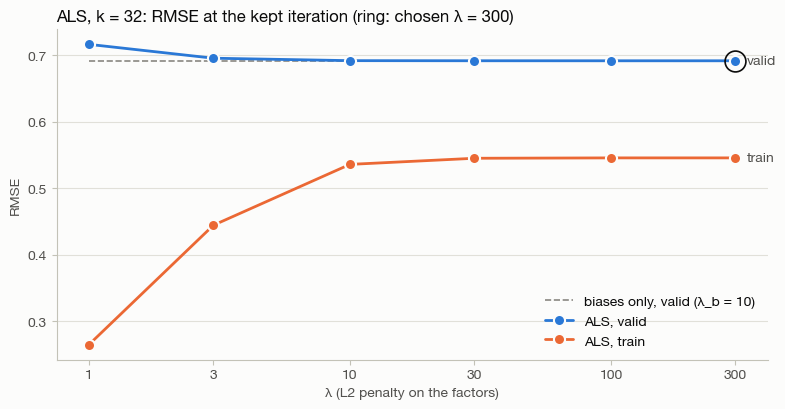

In [7]:
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
VIZ_STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
}

lambdas = als_search.index.to_numpy()
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.hlines(bias_search.loc[best_l2_bias, "valid rmse"], lambdas[0], lambdas[-1], colors=MUTED, linewidths=1.2,
              linestyles="--", label=f"biases only, valid (λ_b = {best_l2_bias:g})")
    for column, color, name in (("valid rmse", BLUE, "valid"), ("train rmse", ORANGE, "train")):
        ax.plot(lambdas, als_search[column], color=color, lw=2, marker="o", ms=8, mec=SURFACE, mew=1.5,
                solid_capstyle="round", solid_joinstyle="round", label=f"ALS, {name}")
        ax.annotate(name, (lambdas[-1], als_search[column].iat[-1]), xytext=(8, 0), textcoords="offset points",
                    va="center", color=INK_2)
    # The chosen lambda: a ring around its valid point.
    ax.plot(best_l2, als_search.loc[best_l2, "valid rmse"], marker="o", ms=15, mfc="none", mec=INK, mew=1.2)
    ax.set_xscale("log")
    ax.set_xticks(lambdas, [f"{value:g}" for value in lambdas])
    ax.minorticks_off()
    ax.set(xlabel="λ (L2 penalty on the factors)", ylabel="RMSE",
           title=f"ALS, k = {FACTORS}: RMSE at the kept iteration (ring: chosen λ = {best_l2:g})")
    ax.grid(axis="x", visible=False)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

## Test

The chosen models next to the global mean. `test, recipe in train` keeps only the test rows whose recipe has a train
rating. On the other rows every model predicts from $\mu$ and $b_u$ alone, so this subset shows what the factors add.

In [8]:
bias_model, als_model = bias_runs[best_l2_bias][0], als_runs[best_l2][0]
test_users, test_recipes, test_values = encoded["test"]
in_train = test_recipes >= 0
eval_rows = {"valid": encoded["valid"], "test": encoded["test"],
             "test, recipe in train": (test_users[in_train], test_recipes[in_train], test_values[in_train])}
models = {
    "global mean": lambda users, recipes: np.full(len(users), R.data.mean()),
    f"biases only (λ_b={best_l2_bias:g})": lambda users, recipes: predict(bias_model, users, recipes),
    f"ALS k={FACTORS} (λ={best_l2:g}, λ_b={best_l2_bias:g})": lambda users, recipes: predict(als_model, users, recipes),
}
results = pd.DataFrame({(model, split): regression_metrics(values, score(users, recipes))
                        for model, score in models.items()
                        for split, (users, recipes, values) in eval_rows.items()}).T.rename_axis(["model", "split"])
display(results.round(4).unstack("split").swaplevel(axis=1).sort_index(axis=1))
print(f"{(~in_train).mean():.1%} of test rows have a recipe with no train rating.")

split                       test                 test, recipe in train  \
                             mae     mse    rmse                   mae   
model                                                                    
ALS k=32 (λ=300, λ_b=10)  0.4308  0.4758  0.6898                0.4207   
biases only (λ_b=10)      0.4308  0.4758  0.6898                0.4207   
global mean               0.4875  0.5256  0.7250                0.4786   

split                                      valid                  
                             mse    rmse     mae     mse    rmse  
model                                                             
ALS k=32 (λ=300, λ_b=10)  0.4551  0.6746  0.4333  0.4785  0.6917  
biases only (λ_b=10)      0.4551  0.6746  0.4333  0.4785  0.6917  
global mean               0.5033  0.7094  0.4950  0.5356  0.7319

10.3% of test rows have a recipe with no train rating.


## Save the model

`model_artifacts/mf_als/` holds:

- `als_model.npz`: `mu`; `user_bias` and `user_factors`, one row per entry of `user_ids`; `item_bias` and `item_factors`, one row per entry of `recipe_ids`.
- `l2_search.csv` (both searches), `metrics.csv` (the table above), and `config.json` (data filters, split, and hyperparameters).

To score user $u$ on recipe $i$, add $\mu$, $b_u$, $c_i$, and $p_u^\top q_i$, leaving out the terms of a user or recipe that is not
in the vocabulary, then clip to [1, 5].

In [9]:
ALS_DIR.mkdir(parents=True, exist_ok=True)
np.savez(ALS_DIR / "als_model.npz", user_ids=user_ids, recipe_ids=recipe_ids, mu=als_model["mu"],
         user_bias=als_model["user_bias"], user_factors=als_model["user_factors"],
         item_bias=als_model["item_bias"], item_factors=als_model["item_factors"])
pd.concat({"biases only": bias_search.rename_axis("l2"), f"ALS k={FACTORS}": als_search.rename_axis("l2")},
          names=["model"]).to_csv(ALS_DIR / "l2_search.csv")
results.to_csv(ALS_DIR / "metrics.csv")
(ALS_DIR / "config.json").write_text(json.dumps({
    "task": "explicit rating regression: biased matrix factorization fitted by ALS",
    "data": str(DATA_PATH.relative_to(NOTEBOOK_DIR)), "target": "rating", "rating_range": [RATING_MIN, RATING_MAX],
    "min_user_ratings": MIN_USER_RATINGS,
    "split": "per user by date: latest rating -> test, the one before -> valid, the rest -> train",
    "users": len(user_ids), "recipes": len(recipe_ids), "train_ratings": int(R.nnz),
    "factors": FACTORS, "l2": best_l2, "l2_bias": best_l2_bias, "l2_grid": L2_GRID, "l2_bias_grid": L2_BIAS_GRID,
    "iterations": int(als_model["iterations"]), "init_std": INIT_STD, "random_state": RANDOM_STATE,
}, indent=2))
print(f"Saved to {ALS_DIR}: {sorted(p.name for p in ALS_DIR.iterdir())}")

Saved to /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/mf_als: ['als_model.npz', 'config.json', 'l2_search.csv', 'metrics.csv']
